# Computer Vision - Semantic Segmentation in Underwater Imagery

# Emanuel Silva - up202402627
# Pedro Almeida - up202105715

In [ ]:
!git clone https://github.com/emanusilva2003/Assignment_2_ComputerVision

## Introduction

Underwater object segmentation is crucial for enabling autonomous underwater robotics,
providing essential scene understanding capabilities that directly support critical marine
exploration and intervention tasks. AUVs (Autonomous Underwater Vehicles) and ROVs
(Remotely Operated Vehicles) require **robust object segmentation techniques** to be able to
distinguish between critical elements like marine structures, biological organisms, geological features, and potential hazards, which is fundamental for safe and effective underwater
operations.

The experiment was conducted using a SUIM (Segmentation of Underwater IMagery) dataset holding object categories for fish, reefs, aquatic plants,
and wrecks/ruins, which are of primary interest in many
underwater exploration and surveying applications. Contains 1525 natural
underwater images and their ground truth semantic labels;
it also includes a test set of 110 images.

The main goal was to beat the original paper results, IoU and F1score, by exploring and adapting already existing SOTA models. The previous work developed 2 different models, 1 lightweight based in RSBs (residual skip blocks ) as encoder and another (heavier) based in the already known VGG architecture. All of models for comparison were translated to the Pytorch library and kept the same  assumptions and hyperparameters presented in the original codebase. We faced performance issues when trying to replicate the original Keras architecture.

The proposed model adopts a SWIN Transform Architecture as its backbone being built by
replacing the standard multi-head self attention (MSA)
module in a Transformer block by a module based on
shifted windows.

----------------------------------------------------------

##Methodology

###**2.1** Dataset SUIM

The work uses the SUIM – Segmentation of Underwater Imagery dataset, composed of 1,525 natural images with pixel-level annotations and an additional set of 110 test images, as described in the original paper. The dataset includes eight semantic categories, each represented by a 3-bit RGB code, as shown in the figure below. 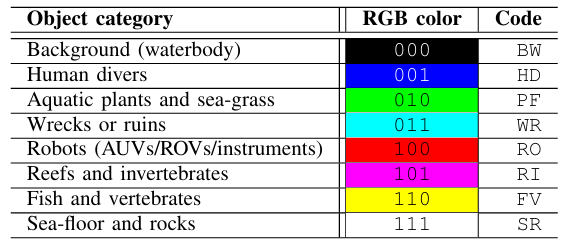


The paper also presents the distribution of the number of images containing each class, highlighting a significant imbalance between categories. This distribution is therefore important to contextualize potentially lower performance in the RO class, given the limited number of examples available for learning.


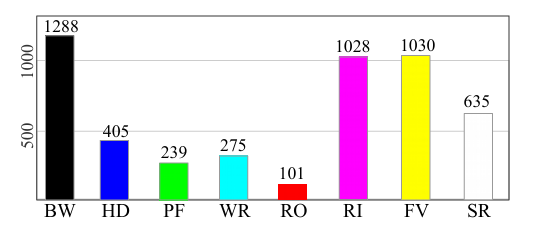


For this project, the provided train_val set was split into 80% for training and 20% for validation, preserving the division established by the authors and respecting the original class distribution.

With the goal of replicating, as closely as possible, the training conditions described in the SUIM-Net paper, the exact same augmentation parameters mentioned in the paper were used:

    'rotation_range': 0.2,

    'width_shift_range': 0.05,

    'height_shift_range': 0.05,

    'shear_range': 0.05,

    'zoom_range': 0.05,

    'horizontal_flip': True


###2.2 **Conversion of the original models to PyTorch**

Before proposing a new model, we began by reimplementing in PyTorch the two models presented in the SUIM-Net paper, with the aim of reproducing the behavior and performance reported in the original work.

Below is a brief description of the architecture of each model:

**SUIM-NetRSB** — a lightweight version based on Residual Skip Blocks (RSB).
Each RSB groups three convolutions (1×1 → 3×3 → 1×1), each followed by BN and ReLU, and may include an additional skip connection for local residual learning.

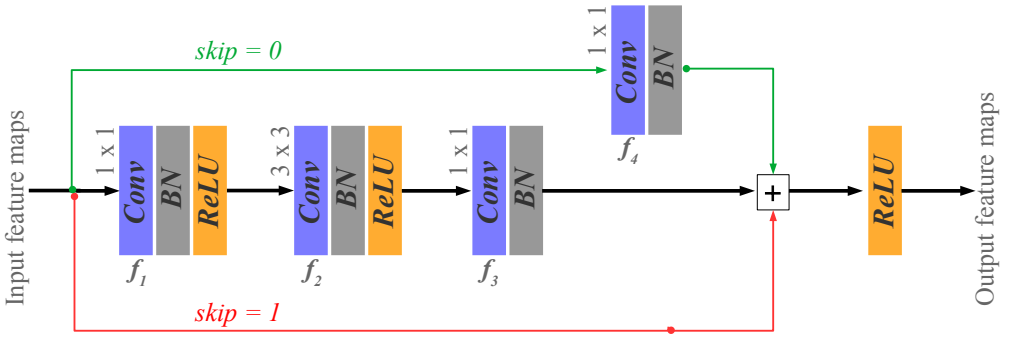
The encoder is composed of seven RSBs organized into three levels (64, 128, and 256 filters), each progressively reducing the spatial resolution. The decoder applies three mirrored DeConv blocks, each receiving skip connections from the corresponding encoder levels.

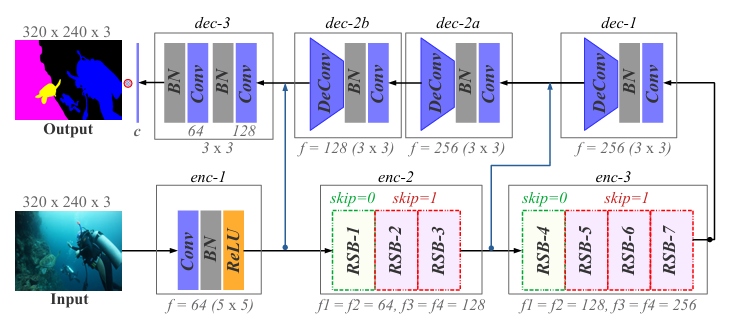


**SUIM-NetVGG** — The heavier version is built from the first four convolutional blocks of VGG16 (64 → 128 → 256 → 512 filters).
The decoding stage mirrors this structure with three upsampling blocks, reducing the channels to 384, then 192, and finally producing the class maps. As in the previous model, the decoder receives symmetric skip connections from the encoder, preserving spatial details.

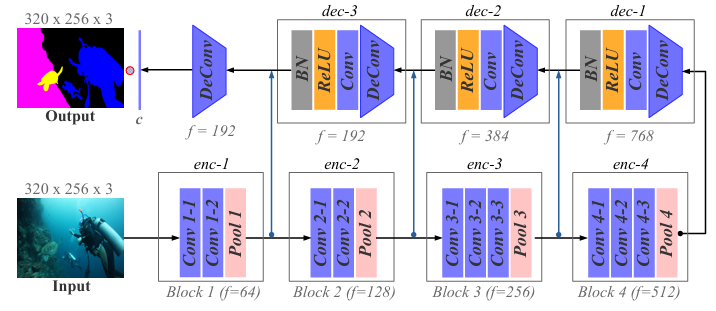

The encoder reduces the resolution across multiple stages while expanding the number of channels to capture deep semantic information.

The decoder reconstructs the semantic map using upsampling, convolutions, and skip connections, producing a final mask with C channels (C = number of classes).


##2.3 **Modelo Proposto: Encoder Swin Transformer + Decoder tipo UNet**

Following the reproduction of the original SUIM-Net models, we developed a third architecture based on the Swin Transformer, motivated by its strong performance in vision tasks and its ability to model both local and global context efficiently. The model retains the classical encoder–decoder structure used in SUIM-Net, but replaces the convolution-based encoder with a hierarchical transformer backbone.

The encoder begins with patch partitioning, where the input image is divided into fixed-size non-overlapping patches. Each patch is converted into a feature vector through linear embedding, forming the initial input tokens for the transformer. These tokens are processed inside local windows using Window Multi-Head Self-Attention (W-MSA). To avoid isolated window effects and enable information flow across regions, the Swin Transformer alternates W-MSA with Shifted Window MSA (SW-MSA). This combination allows the model to capture spatial relationships at different scales while maintaining high computational efficiency — an important property for underwater images, which often suffer from turbidity, low contrast and ambiguous structures.

Across the four transformer stages, patch merging progressively reduces the spatial resolution while increasing the number of channels, producing a multi-scale representation. In our implementation, the encoder outputs feature maps at the following resolutions:

Stage 1: H/4 × W/4, 96 channels

Stage 2: H/8 × W/8, 192 channels

Stage 3: H/16 × W/16, 384 channels

Stage 4: H/32 × W/32, 768 channels

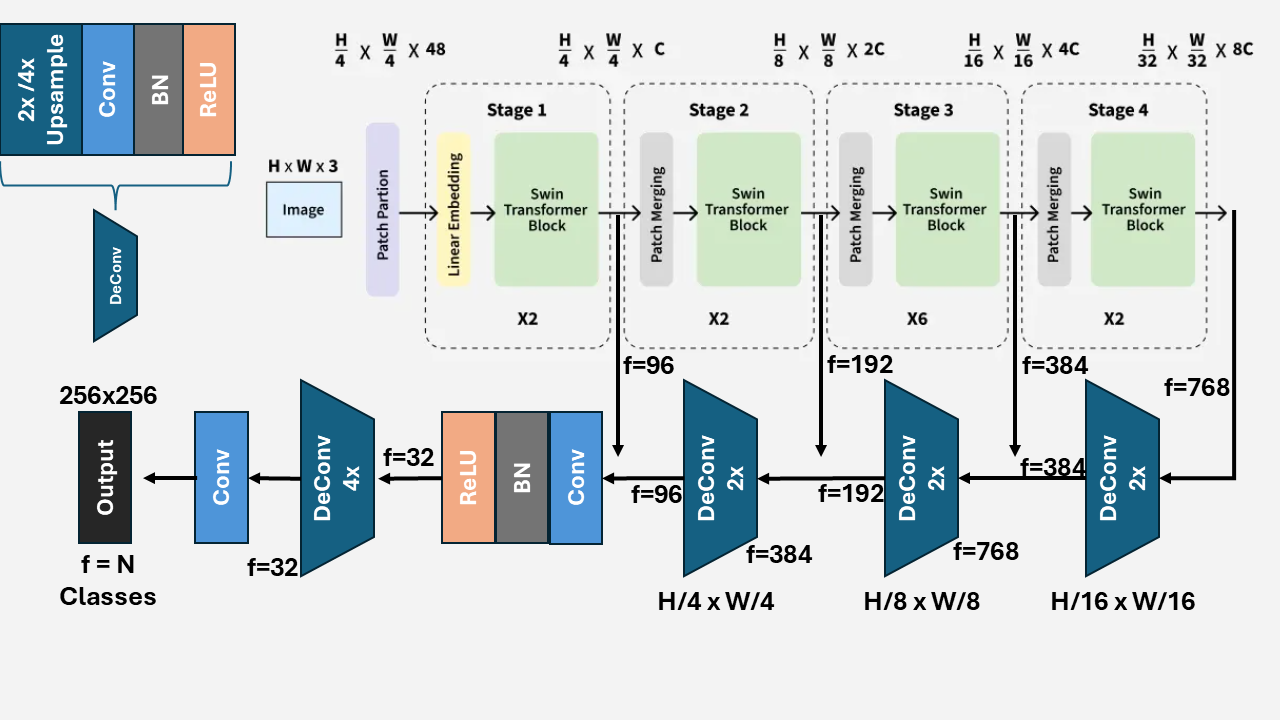

SWIN Transformer Block Architecture

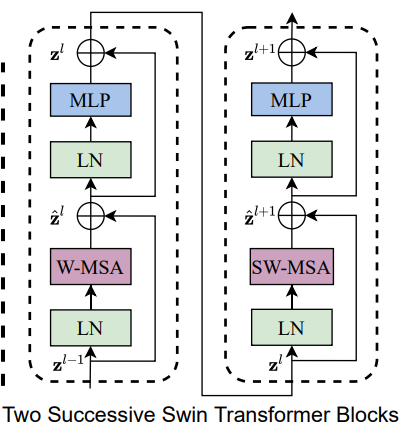

This hierarchical structure enables the capture of low-level patterns in early stages and high-level semantic concepts in deeper stages, which is essential for underwater segmentation where object shapes vary considerably (e.g., fish, reefs, plants or equipment).

The decoder follows a UNet-style reconstruction strategy. Starting from the deepest transformer features, each stage applies bilinear ×2 upsampling followed by convolution, batch normalization and ReLU. The upsampled representation is concatenated with the corresponding encoder output through skip connections, ensuring that fine-grained spatial details lost during downsampling are recovered. This process is repeated across all levels until the original resolution is restored, producing the final dense segmentation map.


### 2.4 **Training and hyperparameters definition**

For the SUIM-Net models (RSB and VGG), the main objective was to replicate the training conditions described by the authors, ensuring that the results obtained were comparable to those reported in the original paper. Therefore, the exact hyperparameters provided in the official codebase were adopted:

- Batch size of 8;

- Adam optimizer with an initial learning rate of 1×10⁻⁴;

- Binary Cross-Entropy as the loss function, applied independently to each channel of the predicted mask;

- The number of epochs was not fixed in advance; instead, training was continued until clear convergence of the training loss or stabilization of the minimum validation loss was observed.

Additionally, training was performed both with and without data augmentation, while keeping all remaining conditions identical. This allowed isolating the contribution of augmentation to the performance improvements in the baseline models.

In the case of the proposed model with a Swin Transformer backbone, periodic oscillations in the loss (loss spikes) were initially observed, suggesting numerical instability during parameter updates. To mitigate this behavior, specific adjustments to the training hyperparameters were introduced:

- The batch size was increased to 16, providing more stable gradient estimates and reducing statistical variability between batches.

- The option drop_last=True was enabled to ensure that the last batch of each epoch was discarded, preventing undesirable distortions in normalization and in the loss computation.

- Finally, the value of eps in the BatchNorm2d layers was increased, improving numerical stability during normalization—an important factor for deep models that rely on consistent batch statistics.

BatchNorm2d Formula with ε:

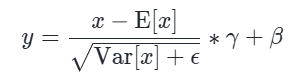

-------------------------------------------


#3.Results

##3.1 Model Complexity and Inference Time

Regarding model complexity, a significant difference can be observed in the number of parameters across the evaluated architectures.

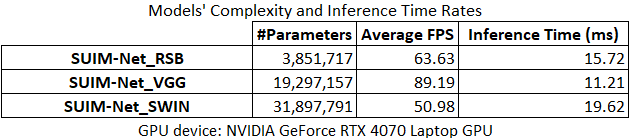

While the SUIM-Net with an RSB backbone contains approximately 3.8 million parameters, the VGG-based and Swin Transformer-based variants increase this complexity to around 19.3 million and 31.9 million parameters, respectively.

Despite this substantial increase in complexity, inference time does not grow proportionally. In particular, the VGG-based model achieves the highest frames-per-second (FPS) rate, suggesting that classical convolutional architectures continue to benefit from highly efficient GPU-level optimizations. Conversely, the Swin Transformer, although considerably heavier, maintains an acceptable inference performance, highlighting a trade-off between representational capacity and computational cost.  


The following figure presents the training and validation loss curves obtained for the implementations developed in this work, namely the SUIM-Net variants with RSB, VGG, and Swin Transformer backbones, trained with and without data augmentation.


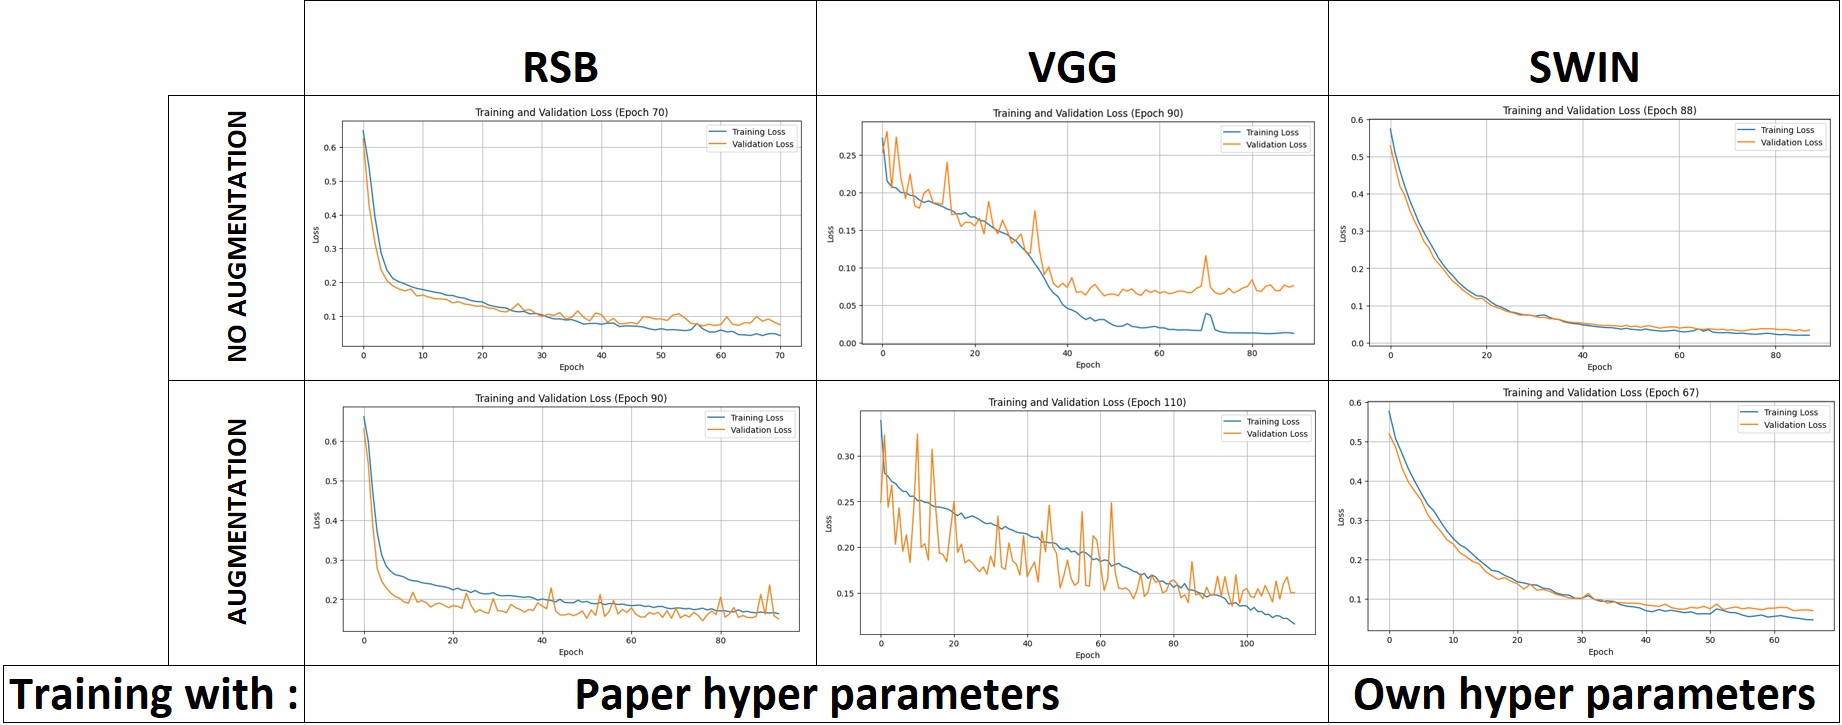

During training, the best validation loss was always drawn without augmentation,
with SWIN having the minimum result: **0.0340** at epoch 87;
**All the epochs near the elbows were tested, and in case of better performance saved for mask generation**. Higher noise was observed for RSB and VGG which might be a result of not dropping the last batch as well as having a smaller batch size.

##3.2 Quantitative Comparison – mIoU e F1
The quantitative analysis of the results, based on the mIoU and F1-Score metrics, allows for an objective comparison of the performance of the different architectures.

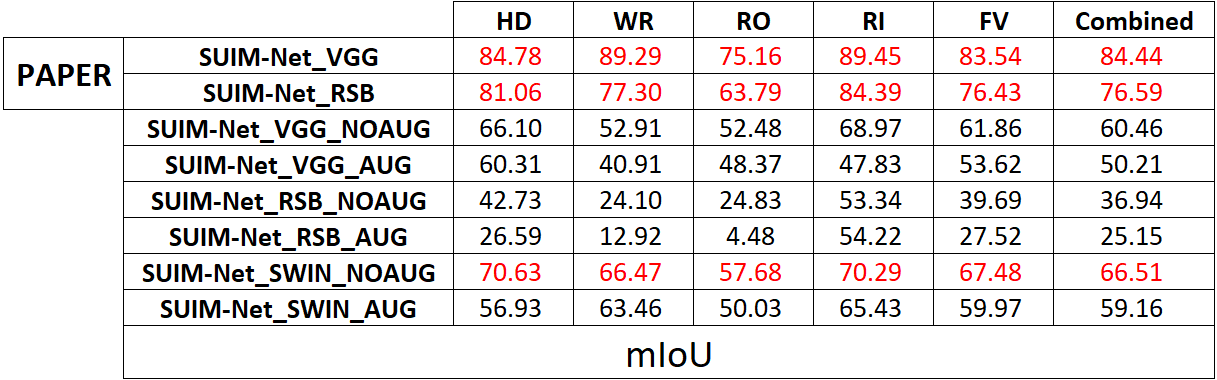

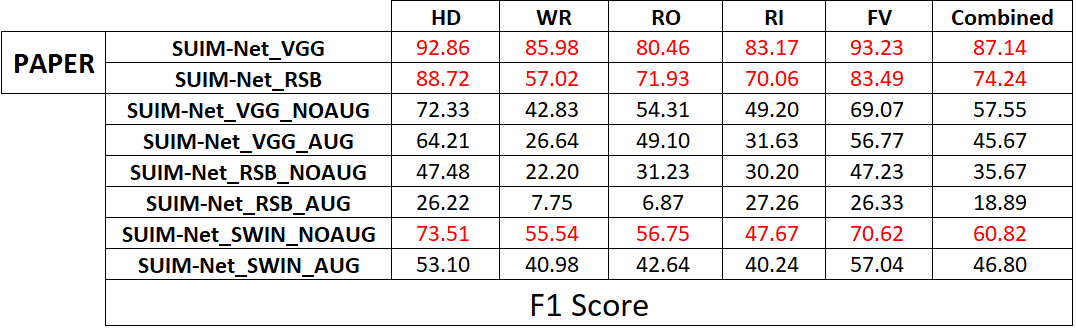

Overall, the mIoU and F1 results show that, among the models evaluated in this work, the architecture based on the Swin Transformer achieves the best overall performance, while the RSB model presents the lowest results. It is also observed that the application of data augmentation consistently leads to a degradation in performance. It is important to note that, despite these results, the obtained values remain significantly below those reported for the original SUIM-Net.
| Modelo / Fonte                    |    mIoU  | F1-score |
| --------------------------------- | -------- | -------- |
| **SUIM-Net-SWIN**                 | **66.5** | **60.8** |
| **SUIM-Net (Paper)**              | **84.4** | **87.1** |

##3.3 Qualitive analysis
The qualitative comparison of the segmentation masks produced by the different models, with and without data augmentation, is shown below.



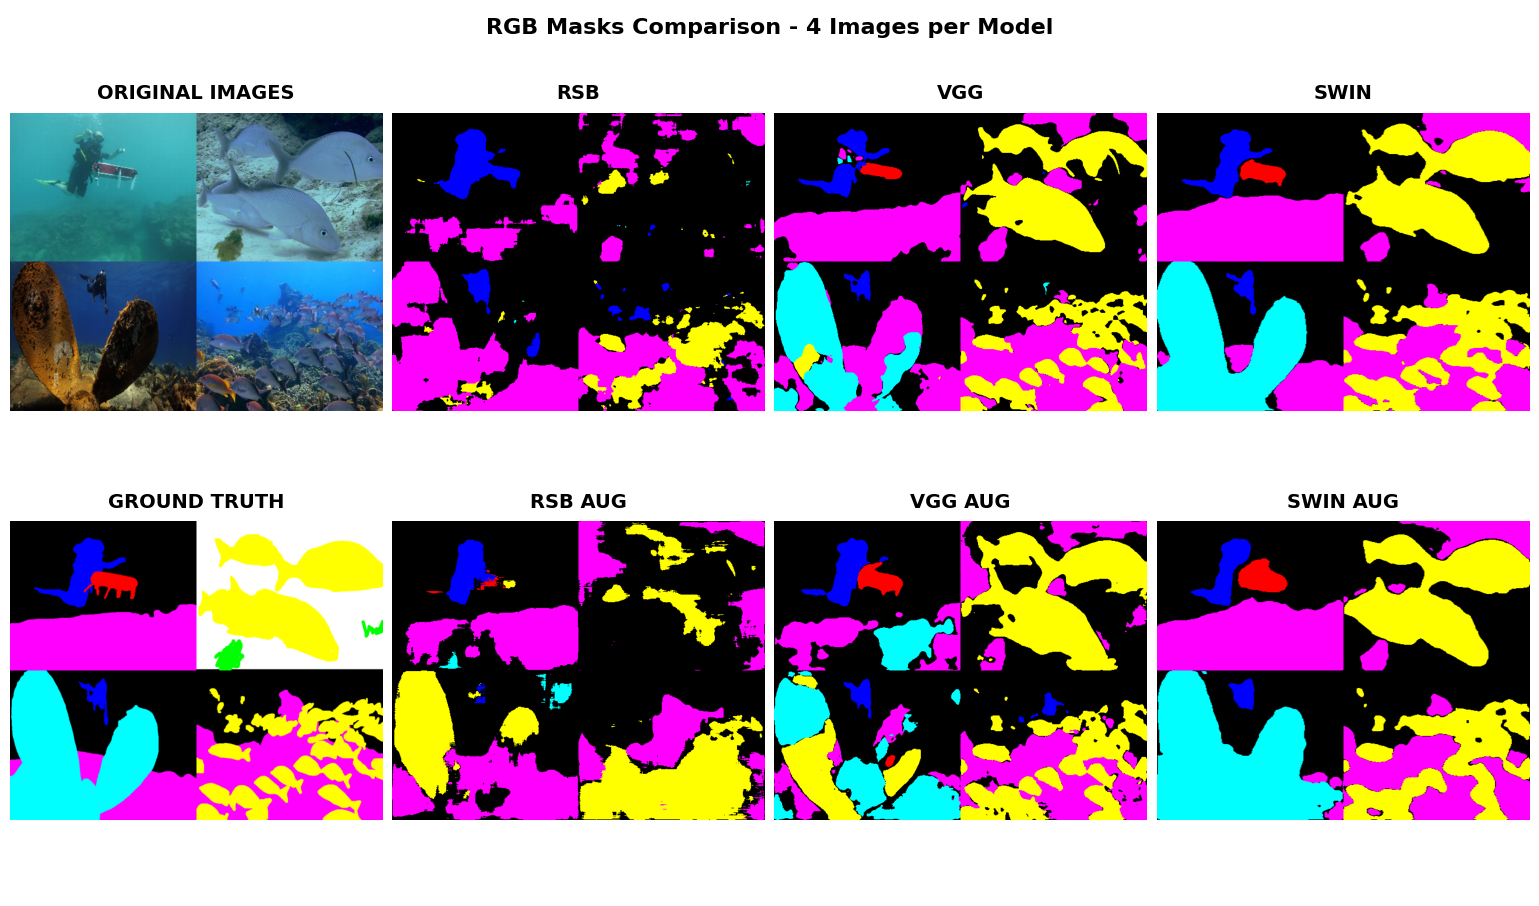

Visually, RSB lasks the overall object detection, with fishes and wrecks not being identified at all. In one hand, VGG does perform better but mixes categories, on the other hand, SWIM has the best segmentation with room for improvement in contours and objects details.

In the end, the code and performance replication failed when comparing the same model written with different libraries. Some of the reasons may include:
- The original code hyperparameters weren't the same as the ones with the best results;
- Some base functions as normalizations and optimizers are implemented in different ways what may diverge the training results;





#4.Future improvements and limitations
The main limitations of this work are related to computational constraints. The limited availability of free GPU resources significantly restricted the number of training configurations that could be explored. Memory constraints also became an issue when training large models and storing multiple checkpoints across several epochs.

Furthermore, the applied data augmentation parameters require revision, as the current configuration negatively impacted model performance. Future work could consider augmentation strategies better suited to underwater environments, such as color-based transformations that more realistically reflect underwater visual conditions.


#5. Conclusion

In this work, the performance of the SUIM-Net architecture for semantic segmentation in underwater images was evaluated by comparing different backbones and analyzing the impact of data augmentation. The model based on the Swin Transformer achieved the best overall performance in terms of mIoU and F1-Score, highlighting the effectiveness of transformer-based architectures in capturing global context in complex underwater scenes.

The VGG and RSB variants, implemented as PyTorch adaptations of versions originally provided in Keras, exhibited lower performance, which can be partially attributed to architectural and implementation differences with respect to the original model described in the paper. Nevertheless, the VGG-based model stood out for offering a favorable trade-off between performance and computational cost, particularly in terms of inference time.

The application of data augmentation consistently led to a degradation in performance, suggesting that the applied transformations did not adequately reflect the visual characteristics of underwater environments. Although the obtained results remain below those reported in the original SUIM-Net paper, this work provides meaningful insights into the impact of architectural choices and training strategies, and points toward future work focusing on more realistic augmentation techniques and more optimized training configurations.

-------------------------------------------------------------------------------


# APPENDIX - Training Pipeline

In [ ]:
# Setup: GPU check and Drive mount
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!git clone https://github.com/emanusilva2003/Assignment_2_ComputerVision

In [ ]:
import sys
repo_path = '/content/Assignment_2_ComputerVision'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
print(f'Repo path: {repo_path}')

In [ ]:
# Imports
import os
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from SUIM.Pytorch.models.suim_net import SUIM_Net
from SUIM.Pytorch.utils.data_utils import get_suim_dataloader, SUIMDataset # Assuming SUIMDataset exists
from torch.utils.data import random_split, DataLoader # Add these imports

In [ ]:
# Configuration
BASE = 'SWIN'  # 'VGG' or 'RSB' or 'SWIN'
BATCH_SIZE = 16
NUM_EPOCHS = 90
CURRENT_EPOCH = 0
CHECKPOINT_FLAG = 0  # 1 IF WE WANT TO START FROM A CHECKPOINT
AUGMENTATION_FLAG = 0
SCHEDULER_FLAG = 0
EPS=1e-3 # 0.1 | Default is 1e-5
NUM_CLASSES= 7 # 5 or 7
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Paths (ajusta o caminho do Drive para o teu dataset)
TRAIN_DIR = '/content/Assignment_2_ComputerVision/SUIM/train_val'
CKPT_DIR = '/content/drive/MyDrive/ckptswin_teste'
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"{BASE} | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS} | Device: {DEVICE}")

In [ ]:
# Data and Model
train_loader,val_loader = get_suim_dataloader(
    train_dir=TRAIN_DIR,
    batch_size=BATCH_SIZE,
    target_size=(320, 256),
    augmentation=AUGMENTATION_FLAG,
    augmentation_params={'rotation_range': 0.2, 'width_shift_range': 0.05,
                        'height_shift_range': 0.05, 'shear_range': 0.05,
                        'zoom_range': 0.05, 'horizontal_flip': True},
    num_workers=2,
    shuffle=True,
    validation=True, # Changed from False to True
    val_ratio=0.2,
    drop_last=True,
    num_classes=NUM_CLASSES
)

model = SUIM_Net(base=BASE, n_classes=NUM_CLASSES, pretrained=False,eps=EPS).to(DEVICE)
total, trainable = model.count_parameters()
print(f"Samples (Train): {len(train_loader.dataset)} | Samples (Validation): {len(val_loader.dataset)} | Params: {total:,}")

In [ ]:
# Training setup
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # VER LR AQUI

if SCHEDULER_FLAG:
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Load the checkpoint and extract the model's state dictionary
if CHECKPOINT_FLAG:
  checkpoint = torch.load("/content/drive/MyDrive/ckptswin_7classes/suimnet_swin_best.pth")
  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  CURRENT_EPOCH = checkpoint['epoch']
  current_history = checkpoint['history']
  history = current_history

  if SCHEDULER_FLAG:
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

  bestmodel = torch.load("/content/drive/MyDrive/ckptswin_7classes/suimnet_swin_best.pth")
  best_val_loss = bestmodel['val_loss']
  epochbestloss = bestmodel['epoch']
  print(f"Loaded checkpoint from epoch {CURRENT_EPOCH} | Best Val. loss {best_val_loss:.4f} from epoch {epochbestloss}")
  CURRENT_EPOCH += 1  # Start from the next epoch
else:
  history = {'loss': [], 'lr': [], 'val_loss': []}
  best_val_loss = float('inf')


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

best_loss = float('inf')

for epoch in tqdm(range(CURRENT_EPOCH, NUM_EPOCHS)):
    model.train()
    epoch_train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Train)")
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_train_loss / len(train_loader)
    history['loss'].append(avg_train_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Validation)")
        for images, masks in val_pbar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            val_loss = criterion(outputs, masks)
            epoch_val_loss += val_loss.item()
            val_pbar.set_postfix({'val_loss': f'{val_loss.item():.4f}'})

    avg_val_loss = epoch_val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {history['lr'][-1]:.2e}")

    if SCHEDULER_FLAG:
        scheduler.step(avg_val_loss)

    # Dynamic plotting
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'Training and Validation Loss (Epoch {epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save best model based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            'val_loss': best_val_loss,
            'history': history,
        }

        if SCHEDULER_FLAG:
            checkpoint_data['scheduler_state_dict'] = scheduler.state_dict()

        torch.save(checkpoint_data, os.path.join(CKPT_DIR, f"suimnet_{BASE.lower()}_best.pth"))

        print(f"  ✓ Best Validation Loss: {best_val_loss:.4f}")

    # Checkpoint every 2 epochs
    if (epoch + 1) % 2 == 0:
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'history': history,
        }
        if SCHEDULER_FLAG:
            checkpoint_data['scheduler_state_dict'] = scheduler.state_dict()

        torch.save(checkpoint_data, os.path.join(CKPT_DIR, f"suimnet_{BASE.lower()}_epoch_{epoch+1}.pth"))
        print(f"  ✓ Checkpoint saved")

print(f"\nCompleted! Best validation loss: {best_val_loss:.4f}")

# SWIN Code

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import swin_t, Swin_T_Weights


class SUIM_Net_Swin(nn.Module):
    """
    SUIM-Net with Swin Transformer Tiny encoder

    Swin-T feature pyramid:
    - Stage 0: H/4  x W/4  x 96   (after patch partition + linear embedding)
    - Stage 1: H/4  x W/4  x 96   (2 Swin blocks)
    - Stage 2: H/8  x W/8  x 192  (2 Swin blocks + patch merging)
    - Stage 3: H/16 x W/16 x 384  (6 Swin blocks + patch merging)
    - Stage 4: H/32 x W/32 x 768  (2 Swin blocks + patch merging)
    """
    def __init__(self, n_classes=5, pretrained=True, eps=1e-5):
        super(SUIM_Net_Swin, self).__init__()

        # Save eps for BatchNorm layers
        self.eps = eps

        # Load Swin Transformer Tiny encoder
        weights = Swin_T_Weights.IMAGENET1K_V1 if pretrained else None
        swin = swin_t(weights=weights)

        # Extract encoder features (all stages)
        self.features = swin.features

        # Feature dimensions at each stage
        # Stage indices: 0(96), 2(96), 4(192), 6(384), 8(768)
        self.stage_indices = [1, 3, 5, 7]  # After each stage (excluding stage 0)
        self.feature_channels = [96, 192, 384, 768]

        # Decoder with skip connections
        # dec-1: 768 → 384 (H/32 → H/16, 2x upsample)
        self.up1 = self._upsample_block(768, 384)

        # dec-2: 384 + 384 (skip) → 192 (H/16 → H/8, 2x upsample)
        self.up2 = self._upsample_block(768, 192)  # 768 = 384 + 384

        # dec-3: 192 + 192 (skip) → 96 (H/8 → H/4, 2x upsample)
        self.up3 = self._upsample_block(384, 96)   # 384 = 192 + 192

        # dec-4: 96 + 96 (skip) → 32 (stays at H/4)
        self.up4 = nn.Sequential(
            nn.Conv2d(192, 32, kernel_size=3, padding=1),  # 192 = 96 + 96
            nn.BatchNorm2d(32, eps=eps),
            nn.ReLU(inplace=True)
        )

        # Final upsampling to original resolution (4x upsample from H/4 to H)
        self.up5 = nn.Sequential(
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32, eps=eps),
            nn.ReLU(inplace=True)
        )

        # Output layer
        self.conv_out = nn.Conv2d(32, n_classes, kernel_size=1)

    def _upsample_block(self, in_channels, out_channels):
        """
        Upsample block: Upsample 2x + Conv + BN + ReLU
        """
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels, eps=self.eps),
            nn.ReLU(inplace=True)
        )

    def _permute_features(self, x):
        """
        Convert Swin output (B, H, W, C) to standard format (B, C, H, W)
        """
        if len(x.shape) == 4 and x.shape[-1] in self.feature_channels:
            # Input is (B, H, W, C) -> permute to (B, C, H, W)
            return x.permute(0, 3, 1, 2)
        return x

    def forward(self, x):
        """
        Forward pass with feature extraction at multiple scales

        Args:
            x: Input tensor (B, 3, H, W)

        Returns:
            out: Output segmentation mask (B, n_classes, H, W)
        """
        # Extract features at different stages
        features = []

        for i, layer in enumerate(self.features):
            x = layer(x)

            # Capture features after each stage (excluding initial patch partition)
            if i in self.stage_indices:
                # Permute if needed: (B, H, W, C) -> (B, C, H, W)
                feat = self._permute_features(x)
                features.append(feat)

        # Features: [stage1 (96), stage2 (192), stage3 (384), stage4 (768)]
        feat1, feat2, feat3, feat4 = features

        # Decoder with skip connections
        # Stage 4 (768 channels, H/32 x W/32) -> dec1 (384 channels, H/16 x W/16)
        dec1 = self.up1(feat4)

        # Match dimensions and concatenate with stage 3 (384 channels)
        dec1 = self._match_dimensions(dec1, feat3)
        dec1 = torch.cat([dec1, feat3], dim=1)  # 768 = 384 + 384

        # dec1 (768) -> dec2 (192 channels, H/8 x W/8)
        dec2 = self.up2(dec1)

        # Match dimensions and concatenate with stage 2 (192 channels)
        dec2 = self._match_dimensions(dec2, feat2)
        dec2 = torch.cat([dec2, feat2], dim=1)  # 384 = 192 + 192

        # dec2 (384) -> dec3 (96 channels, H/4 x W/4)
        dec3 = self.up3(dec2)

        # Match dimensions and concatenate with stage 1 (96 channels)
        dec3 = self._match_dimensions(dec3, feat1)
        dec3 = torch.cat([dec3, feat1], dim=1)  # 192 = 96 + 96

        # dec3 (192) -> dec4 (96 channels, H/4 x W/4)
        dec4 = self.up4(dec3)

        # Final upsampling: H/4 x W/4 -> H x W
        dec5 = self.up5(dec4)

        # Output segmentation mask
        out = self.conv_out(dec5)
        out = torch.sigmoid(out)

        return out

    def _match_dimensions(self, x, target):
        """
        Match spatial dimensions of x to target using padding/cropping

        Args:
            x: Tensor to resize (B, C, H, W)
            target: Target tensor with desired spatial dimensions

        Returns:
            Resized x matching target's spatial dimensions
        """
        _, _, h, w = target.shape
        _, _, x_h, x_w = x.shape

        # Crop if larger
        if x_h > h:
            x = x[:, :, :h, :]
        if x_w > w:
            x = x[:, :, :, :w]

        # Pad if smaller
        if x_h < h or x_w < w:
            pad_h = h - x_h
            pad_w = w - x_w
            x = F.pad(x, (0, pad_w, 0, pad_h))

        return x

    def count_parameters(self):
        """Count total and trainable parameters"""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable
